# Approximate Hybrid Quantum State Preparation for a PPG Signal

## Imports

In [1]:
import sys
sys.path.append("../src")

In [2]:
import numpy as np
import pandas as pd
import os
import math
import matplotlib.pyplot as plt

from hybridqsp.transforms import haar_packet_transform, inverse_haar_packet_transform
from hybridqsp.quantum import build_inverse_qphwt_circuit
from hybridqsp.thresholding import top_k_threshold, magnitude_threshold
from hybridqsp.analysis import search_sparse_haar_representations
from hybridqsp.metrics import state_fidelity, trace_distance

## PPG Signal Loading

A sample PPG signal is loaded from the `ppg_dataset/` directory for hybrid quantum reconstruction experiments.

In [4]:
signal = np.load(
    "../ppg-dataset/ppg_sample.npy"
)

n = 10
N = 2**n

target_f = (
    signal[:N] /
    np.linalg.norm(signal[:N])
)

### Visualization of Signal

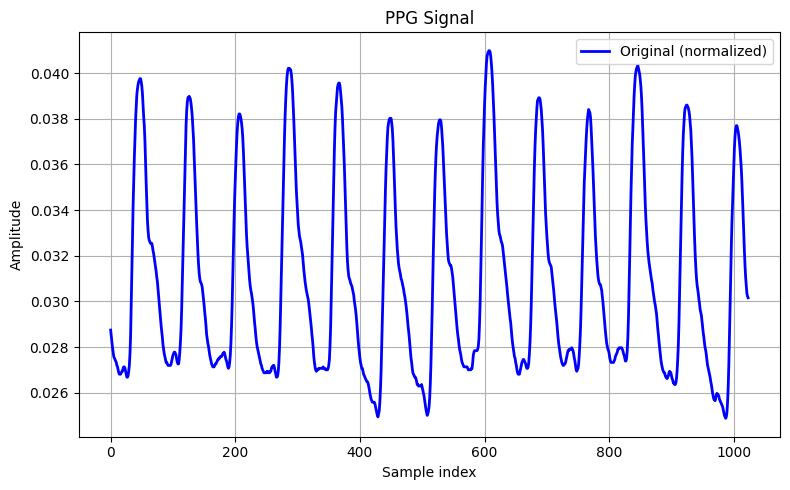

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(target_f, label="Original (normalized)", lw=2, color="blue")

plt.title(f"PPG Signal")
plt.xlabel("Sample index");
plt.ylabel("Amplitude")
plt.grid(True);
plt.legend();
plt.tight_layout();
plt.show()

## Phase I: Compression of the Piecewise Constant Signal
### Classical Sparsity Analysis

The transform-domain coefficients are analyzed in order to identify sparse representations suitable for quantum state preparation.

In [6]:
results = search_sparse_haar_representations(
    signal[:N],
    tolerance=0.04
)

Level=5 | Threshold=3.159e-03 | Nonzero=539 | Sparsity=0.526 | Trace Distance=2.058385e-03 | Fidelity=0.999996
Level=5 | Threshold=6.317e-03 | Nonzero=397 | Sparsity=0.388 | Trace Distance=4.284968e-03 | Fidelity=0.999982
Level=5 | Threshold=1.579e-02 | Nonzero=247 | Sparsity=0.241 | Trace Distance=9.700341e-03 | Fidelity=0.999906
Level=5 | Threshold=3.159e-02 | Nonzero=156 | Sparsity=0.152 | Trace Distance=1.785572e-02 | Fidelity=0.999681
Level=5 | Threshold=6.317e-02 | Nonzero=94 | Sparsity=0.092 | Trace Distance=3.061940e-02 | Fidelity=0.999062
Level=6 | Threshold=4.049e-03 | Nonzero=538 | Sparsity=0.525 | Trace Distance=2.706252e-03 | Fidelity=0.999993
Level=6 | Threshold=8.098e-03 | Nonzero=399 | Sparsity=0.390 | Trace Distance=5.420671e-03 | Fidelity=0.999971
Level=6 | Threshold=2.024e-02 | Nonzero=238 | Sparsity=0.232 | Trace Distance=1.232881e-02 | Fidelity=0.999848
Level=6 | Threshold=4.049e-02 | Nonzero=146 | Sparsity=0.143 | Trace Distance=2.197614e-02 | Fidelity=0.999517
Le

In [30]:
# Apply 10-level discrete packet Haar wavelet transformation on sinc signal
level = 6
X = haar_packet_transform(signal[:N], level)

In [31]:
# apply top-k threshold on the transformed data for k =110

k = 110
Xr = top_k_threshold(X, k)

### Normalization

In [32]:
X_norm = Xr/np.linalg.norm(Xr)

### Classical Signal Reconstruction

In [33]:
x_rec = inverse_haar_packet_transform(X_norm, level)

### Trace Distance

In [34]:
TD = trace_distance(x_rec, target_f)

### Visualization

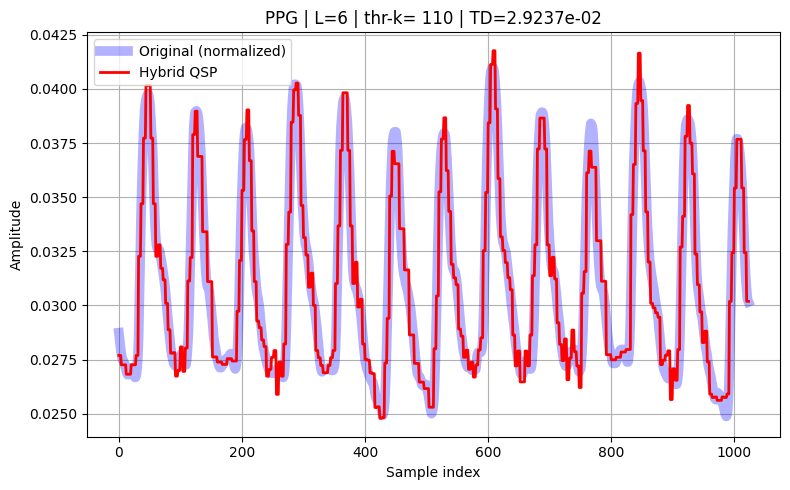

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(target_f, 'blue', lw=7, alpha=0.3, label="Original (normalized)")
plt.plot(x_rec, lw=2, color="red", label="Hybrid QSP")
plt.title(f"PPG | L={level} | thr-k= {k} | TD={TD:.4e}")
plt.xlabel("Sample index");
plt.ylabel("Amplitude")
plt.grid(True);
plt.legend();
plt.tight_layout();

plt.savefig("../figures/PPG_signal_preparation.pdf")
plt.show()

## Phase II: Quantum Decompression
The sparse Haar-domain representation is normalized and encoded into a quantum state. The inverse Quantum Packet Haar Wavelet Transform is then applied in order to reconstruct the original signal quantum mechanically.

In [36]:
from qibo import Circuit, gates
from qibo.models.encodings import sparse_encoder
from qibo.ui import plot_circuit

In [37]:
# Sparse transform-domain coefficient vector
vec = X_norm

# Indices of nonzero coefficients
nz = np.flatnonzero(vec)

# Total number of qubits required
# for amplitude encoding
nqubits = int(np.log2(len(vec)))

# Construct sparse basis-state representation
# as (bitstring, amplitude) pairs
y = [
    (format(i, f"0{nqubits}b"), vec[i])
    for i in nz
]

# Prepare sparse quantum state using
# the Farias SQSP method
qc = sparse_encoder(
    y,
    method="farias"
)

# Construct inverse quantum Haar packet
# wavelet transform circuit
iqphwt = build_inverse_qphwt_circuit(
    n=nqubits,
    level=level
)

# Apply inverse quantum transformation
# for signal reconstruction
qc.add(
    iqphwt.on_qubits(*range(nqubits))
)

# Display decomposed circuit statistics
# for quantum resource analysis
print(
    qc.decompose().decompose().summary()
)

[Qibo 0.3.4|INFO|2026-07-02 00:35:26]: Using numpy backend on /CPU:0


Circuit depth = 814
Total number of gates = 1192
Number of qubits = 10
Most common gates:
cx: 619
x: 304
ry: 231
h: 38
None


## Statevector of the Quantum SQSP and Quantum Decompression

In [38]:
result = qc()

state = result.state()

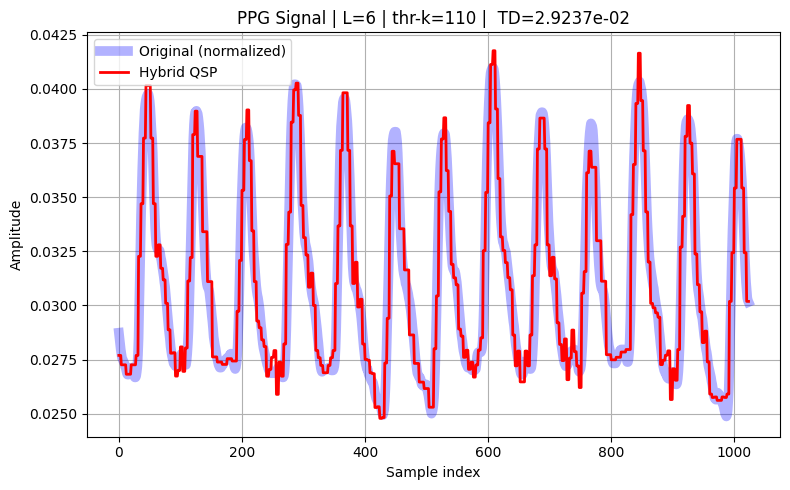

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(target_f, 'blue', lw=7, alpha=0.3, label="Original (normalized)")
plt.plot(state.real, lw=2, color="red", label="Hybrid QSP")
plt.title(f"PPG Signal | L={level} | thr-k={k} |  TD={TD:.4e}")
plt.xlabel("Sample index");
plt.ylabel("Amplitude")
plt.grid(True);
plt.legend();
plt.tight_layout();
plt.show()